<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Matrices, Images and Coordinates in Numpy
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>March, 2026</font></center>

***

# Import libraries

In [4]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

# load MATLAB colormap: parula
mat = scipy.io.loadmat("parula.mat")
parula_rgb = mat["P"]
parula_map = ListedColormap(parula_rgb)

plt.rcParams["font.family"] = "Helvetica"
# rc('text', usetex=True)
%matplotlib inline
%config InlineBackend.figure_format = 'svg'


# A simple 2x2 matrix test

In [5]:
A = np.array([[1, 2], [3, 4]])

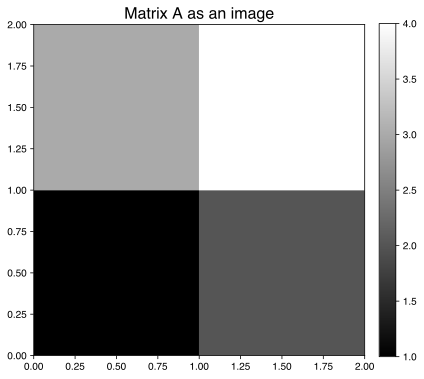

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(A, cmap="gray", origin="lower", extent=[0, A.shape[1], 0, A.shape[0]])
ax.set_aspect("equal")
ax.set_title("Matrix A as an image", fontsize=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

# Pupil coordinates in k space

In [7]:
num = 2**8-1

In [8]:
kx = np.linspace(-1, 1, num=num)
ky = np.linspace(1, -1, num=num)

X, Y = np.meshgrid(kx, ky)

In [9]:
field_factor = 1
num_ex, num_ey = num*field_factor, num*field_factor
lda = 0.500
lx, ly = num_ex*lda/2, num_ey*lda/2
dx, dy = lx/num_ex, ly/num_ey

x = np.arange(num_ex)*dx
y = np.arange(num_ey)*dy
X, Y = np.meshgrid(x, y)

In [10]:
I0, Ip1, In1 = 0.8, 0.5, 0.5
k0 = 2*np.pi/lda
amp_0, amp_p1, amp_n1 = np.sqrt(I0), np.sqrt(Ip1), np.sqrt(In1)

# Use exact DFT-bin frequencies so the FFT peaks fall on single pixels.
dkx = 2*np.pi/(num_ex*dx)
dky = 2*np.pi/(num_ey*dy)
mx0, my0 = 0, 0
mx_shift = 64

kx0, ky0 = mx0*dkx, my0*dky
kx_p1, ky_p1 = (mx0 + mx_shift)*dkx, my0*dky
kx_n1, ky_n1 = (mx0 - mx_shift)*dkx, my0*dky

# # User-defined frequencies, not necessarily on DFT bins. FFT peaks will be spread over multiple pixels.
# kx0, ky0 = 0.0*k0, 0.0*k0
# kx_p1, ky_p1 = kx0 + 0.5*k0, ky0
# kx_n1, ky_n1 = kx0 - 0.5*k0, ky0

fft_floor = 1e-5

print(f"k0 = {k0:.3f}")
print(f"kx0 = {kx0:.3f}, ky0 = {ky0:.3f}")

k0 = 12.566
kx0 = 0.000, ky0 = 0.000


In [11]:
field_total = amp_0*np.exp(1j*(kx0*X+ky0*Y)) + amp_p1 * \
    np.exp(1j*(kx_p1*X+ky_p1*Y)) + amp_n1*np.exp(1j*(kx_n1*X+ky_n1*Y))
field_intensity = np.abs(field_total) ** 2

In [12]:
pupil_fft = np.fft.fftshift(np.fft.fft2(field_total)) / (num_ex * num_ey)
pupil_intensity = np.flipud(np.abs(pupil_fft))**2
pupil_intensity_max = max(I0, Ip1, In1)
pupil_intensity_peak = pupil_intensity.max()
pupil_intensity_peak


0.8000000000000004

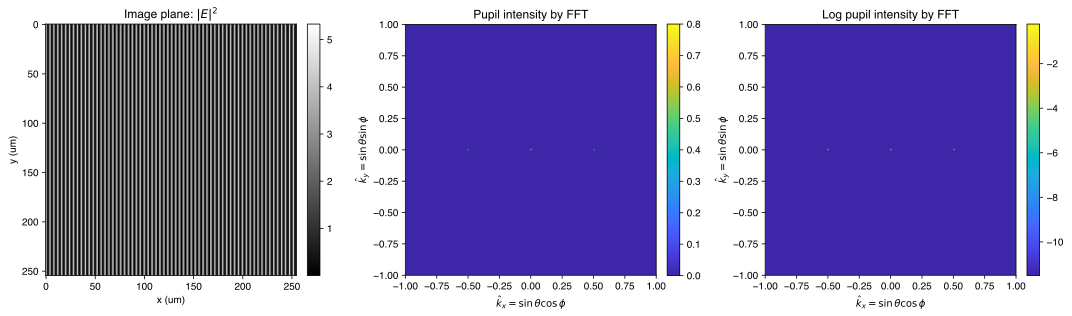

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(5 * 3, 4.5))
im0 = ax[0].imshow(
    field_intensity,  # add a small constant to avoid log(0)
    # extent=[0, lx, 0, ly],
    aspect="auto",
    cmap="gray",
)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title(r"Image plane: $|E|^2$")

im1 = ax[1].imshow(
    pupil_intensity,
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    # vmin=0,
    # vmax=pupil_intensity_max,
)
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
ax[1].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[1].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[1].set_title("Pupil intensity by FFT")

im2 = ax[2].imshow(
    np.log(pupil_intensity+fft_floor),  # add a small constant to avoid log(0)
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    # vmin=0,
    # vmax=pupil_intensity_max,
)
ax[2].set_aspect("equal")
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
ax[2].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[2].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[2].set_title("Log pupil intensity by FFT")

fig.tight_layout()

# Intensity when field is local

Multiply the field by a square mask centered in the square region:

$$E_{\mathrm{local}}(x,y)=E(x,y)M(x,y)$$

In Fourier space this becomes a convolution, so each sharp k-space peak is broadened by the FFT of the square mask into a sinc-like spot with sidelobes along both axes. A smaller square gives a wider spot.

If the FFT peak amplitude drops because only a fraction of the area is occupied, there are two common corrections:
 1. For comparing k-space peak amplitude or intensity with the full-field case, normalize by the effective support area of the mask instead of the total area.
 1. For keeping the total real-space power the same, rescale the field inside the mask by $1/\sqrt{f}$, where $f$ is the fill fraction of the mask.

For our case, method 1 is more reasonable.

In [14]:
# Example of finding the top 3 values in a 2D array
def top3(arr):
    return np.sort(arr, axis=None)[-3:][::-1]

In [15]:
# Get the fill fraction of a square aperture in the image plane
xc, yc = x.mean(), y.mean()
side_length = 0.24 * min(lx, ly)
half_side = side_length / 2
mask = (
    (np.abs(X - xc) <= half_side) &
    (np.abs(Y - yc) <= half_side)
).astype(float)

fill_fraction = mask.mean()
support_pixels = mask.sum()
print(f"Fill fraction of the square aperture: {fill_fraction*100:.2f}%")
print(f"Number of pixels in the support: {support_pixels}")
print(f"Number of pixels in the full field: {num_ex * num_ey}, fill fraction: {support_pixels/(num_ex * num_ey)*100:.2f}%")

Fill fraction of the square aperture: 5.72%
Number of pixels in the support: 3721.0
Number of pixels in the full field: 65025, fill fraction: 5.72%


In [16]:
# Apply the mask to the field and compute the local intensity
field_local = field_total * mask
field_intensity_local = np.abs(field_local) ** 2

In [17]:
# Compute the FFT of the local field and its intensity with raw scaling
pupil_fft_local_raw = np.fft.fftshift(
    np.fft.fft2(field_local)) / (num_ex * num_ey)
pupil_intensity_local_raw = np.flipud(np.abs(pupil_fft_local_raw))**2

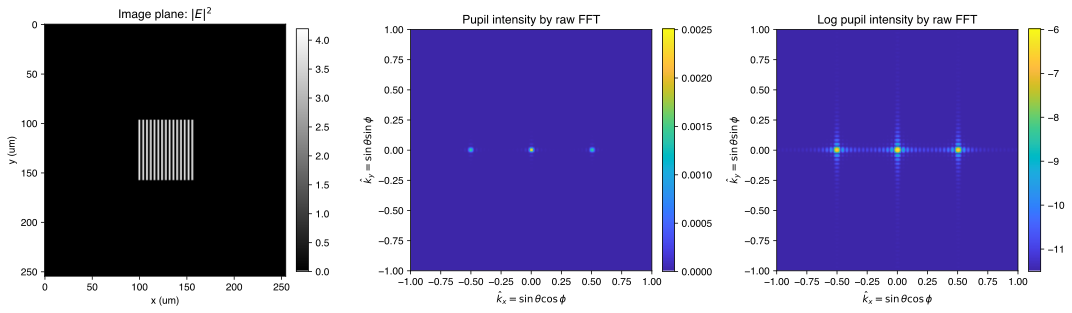

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(5 * 3, 4.5))
im0 = ax[0].imshow(
    field_intensity_local,  # add a small constant to avoid log(0)
    # extent=[0, lx, 0, ly],
    aspect="auto",
    cmap="gray",
)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title(r"Image plane: $|E|^2$")

im1 = ax[1].imshow(
    pupil_intensity_local_raw,
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    vmin=0,
    # vmax=pupil_intensity_max,
)
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
ax[1].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[1].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[1].set_title("Pupil intensity by raw FFT")

im2 = ax[2].imshow(
    # add a small constant to avoid log(0)
    np.log(pupil_intensity_local_raw+fft_floor),
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    # vmin=0,
    # vmax=pupil_intensity_max,
)
ax[2].set_aspect("equal")
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
ax[2].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[2].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[2].set_title("Log pupil intensity by raw FFT")

fig.tight_layout()

In [19]:
# Compute the FFT of the local field and its intensity with support-based scaling
pupil_fft_local_support = np.fft.fftshift(
    np.fft.fft2(field_local)) / (support_pixels)
pupil_intensity_local_support = np.flipud(np.abs(pupil_fft_local_support))**2

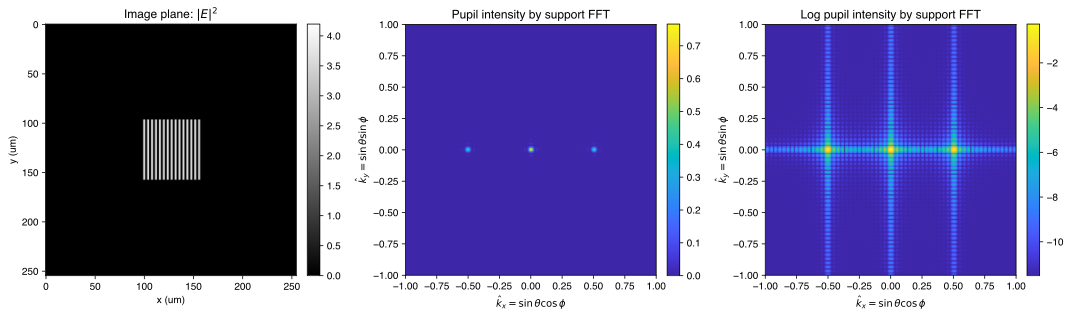

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(5 * 3, 4.5))
im0 = ax[0].imshow(
    field_intensity_local,  # add a small constant to avoid log(0)
    # extent=[0, lx, 0, ly],
    aspect="auto",
    cmap="gray",
)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title(r"Image plane: $|E|^2$")

im1 = ax[1].imshow(
    pupil_intensity_local_support,
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    vmin=0,
    # vmax=pupil_intensity_max,
)
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
ax[1].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[1].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[1].set_title("Pupil intensity by support FFT")

im2 = ax[2].imshow(
    # add a small constant to avoid log(0)
    np.log(pupil_intensity_local_support+fft_floor),
    extent=[-1, 1, -1, 1],
    aspect="auto",
    cmap=parula_map,
    # vmin=0,
    # vmax=pupil_intensity_max,
)
ax[2].set_aspect("equal")
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
ax[2].set_xlabel(r"$\hat{k}_x=\sin\theta\cos\phi$")
ax[2].set_ylabel(r"$\hat{k}_y=\sin\theta\sin\phi$")
ax[2].set_title("Log pupil intensity by support FFT")

fig.tight_layout()

In [21]:
print(f"fill fraction = {fill_fraction*100:.2f}%")
print("top-3 FFT intensities")
print("full field                :", top3(pupil_intensity))
print("local field, raw FFT      :", top3(pupil_intensity_local_raw))
print("local field, support norm :", top3(pupil_intensity_local_support))

fill fraction = 5.72%
top-3 FFT intensities
full field                : [0.8 0.5 0.5]
local field, raw FFT      : [0.00250928 0.00208965 0.00208965]
local field, support norm : [0.7662867 0.6381387 0.6381387]


Use the two corrections for different goals:

- Support normalization keeps the k-space peak amplitude on the same scale as the full-field case.
- The $1/\sqrt{f}$ factor keeps the total real-space power the same, but the FFT spots still stay broader because localization itself changes the spectrum.